# Caderno 3 - Análise da anotação por LLM

## 1. Parâmetros de entrada

In [1]:
ARQUIVO_HUMAN_EVALS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/raw_human_eval.csv'
ARQUIVO_REFERENCE_QRELS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/qrel.csv'
PASTA_LLM_EVAL = './dados/outputs/2 - llm evals/'

In [2]:
MAPA_NOME_MODELO = {
    "deepseek-chat": "deepseek",
    "gpt-5-mini-2025-08-07": "gpt-5-mini",
    "sabiazinho-4-2026-01-06": "sabiazinho-4"
}

# Guarda a ordem da lista de modelos
llm_order = [
    "deepseek_simple",
    "deepseek_cot",
    "gpt-5-mini_simple",
    "gpt-5-mini_cot",
    "sabiazinho-4_simple",
    "sabiazinho-4_cot",
]

## 2. Dataframes com as avaliações

In [3]:
import pandas as pd
import glob

# Carrega o reference qrels e uniformiza as colunas
df_reference_qrels = pd.read_csv(ARQUIVO_REFERENCE_QRELS)
df_reference_qrels = df_reference_qrels.drop(columns=['RANK'])
df_reference_qrels['USUARIO_AVALIADOR'] = 'Reference'
df_reference_qrels = df_reference_qrels.rename(columns={'SCORE': 'AVALIACAO'})

# Carrega as avaliações humanas
df_human_evals = pd.read_csv(ARQUIVO_HUMAN_EVALS)

# Carrega as avaliações com LLM
arquivos_csv = glob.glob(f"{PASTA_LLM_EVAL}/*.csv")
df_llm_evals = pd.concat(
    (pd.read_csv(arquivo) for arquivo in arquivos_csv),
    ignore_index=True
)

# Para df_llm_evals ficar com o mesmo formato de df_human_evals, 
# vamos definir o avaliador como o conjunto MODELO e PROMPT
# e selecionar só as colunas que importam
df_llm_evals["USUARIO_AVALIADOR"] = (
    df_llm_evals["MODELO"].map(MAPA_NOME_MODELO).astype(str) + "_" +
    df_llm_evals["PROMPT"].astype(str)
)

df_llm_evals = df_llm_evals[["QUERY_KEY", "DOC_KEY", "AVALIACAO", "USUARIO_AVALIADOR"]]

df_all_evals = pd.concat(
    [df_reference_qrels, df_human_evals, df_llm_evals],
    ignore_index=True
)

C:\Users\caris\anaconda3\Lib\site-packages\numpy\__init__.py:127: UserWarning: mkl-service package failed to import, therefore Intel(R) MKL initialization ensuring its correct out-of-the box operation under condition when Gnu OpenMP had already been loaded by Python process is not assured. Please install mkl-service package, see http://github.com/IntelPython/mkl-service
  from . import _distributor_init


## 3. Análise das anotações

### 3.1. Distribuição de labels por anotador

Primeiro define uma ordem para mostrar as avaliações

In [4]:
# 1) Humanos (ordem alfabética)
human_order = sorted(df_human_evals["USUARIO_AVALIADOR"].unique().tolist())

eval_order = ['Reference'] + human_order + llm_order

print(eval_order)

['Reference', 'A_1', 'A_2', 'A_3', 'A_4', 'deepseek_simple', 'deepseek_cot', 'gpt-5-mini_simple', 'gpt-5-mini_cot', 'sabiazinho-4_simple', 'sabiazinho-4_cot']



=== Label distribution (counts) per annotator ===
AVALIACAO               0     1     2  Total
USUARIO_AVALIADOR                           
Reference             513   145   154    812
A_1                   536    66   203    805
A_2                   477    80   156    713
A_3                   461   137   207    805
A_4                   451   166   108    725
deepseek_simple       420   237   155    812
deepseek_cot          397   208   207    812
gpt-5-mini_simple     215   332   265    812
gpt-5-mini_cot        216   345   251    812
sabiazinho-4_simple   290   184   338    812
sabiazinho-4_cot      209   306   297    812
Total                4185  2206  2341   8732

=== Label distribution (%) per annotator ===
AVALIACAO               0     1     2
USUARIO_AVALIADOR                    
Reference            63.2  17.9  19.0
A_1                  66.6   8.2  25.2
A_2                  66.9  11.2  21.9
A_3                  57.3  17.0  25.7
A_4                  62.2  22.9  14.9
deepsee

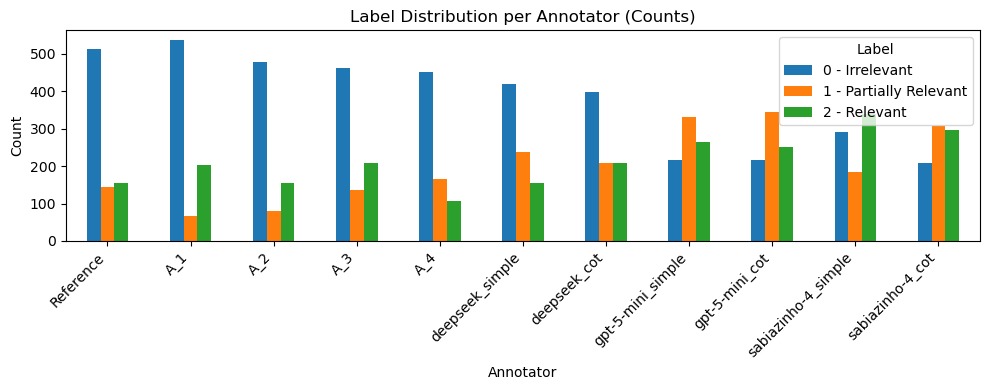

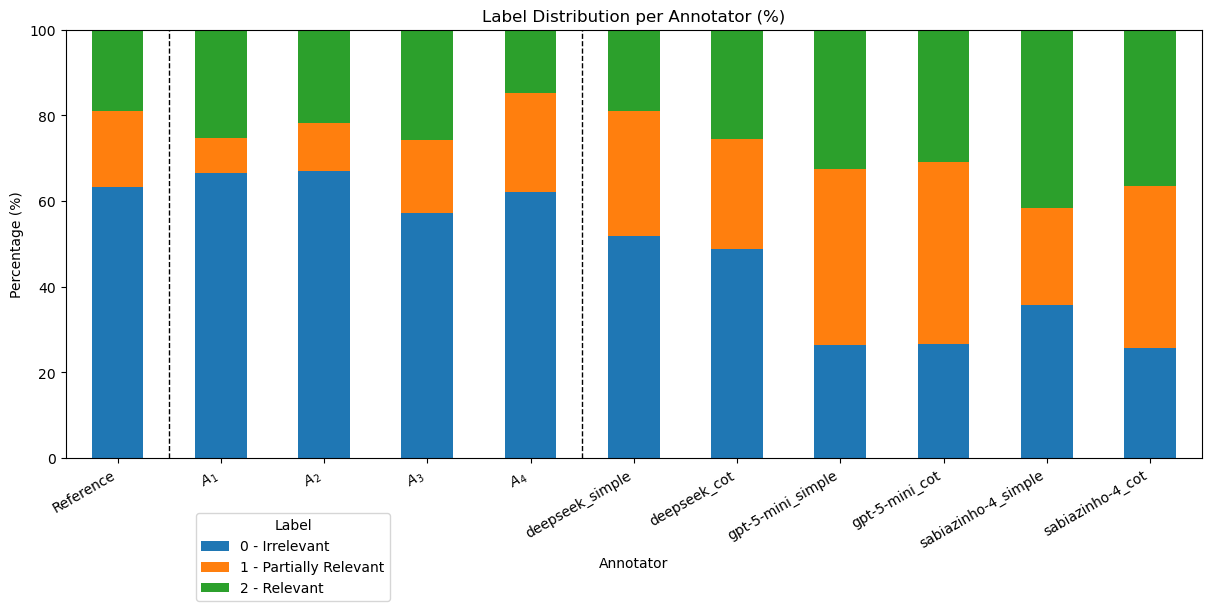

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LEVEL 1 — Individual annotator behavior
# Fixed annotator order: A_1, A_2, A_3, A_4
# ============================================================
df = df_all_evals.copy()

# ============================================================
# 1.1 Tables: label distribution per annotator
# ============================================================

# Absolute counts of labels (0/1/2)
dist_counts = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

# ---- Add row totals (Total per annotator)
dist_counts["Total"] = dist_counts.sum(axis=1)

# ---- Add column totals (Total per label + grand total)
column_totals = dist_counts.sum(axis=0)
dist_counts.loc["Total"] = column_totals

# Percentages (computed BEFORE adding totals row)
dist_pct = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

dist_pct = dist_pct.div(dist_pct.sum(axis=1), axis=0)

# ============================================================
# PRINT TABLES
# ============================================================

print("\n=== Label distribution (counts) per annotator ===")
print(dist_counts)

print("\n=== Label distribution (%) per annotator ===")
print((dist_pct * 100).round(1))

# ============================================================
# PLOTS (unchanged)
# ============================================================

# Remove the totals row for plotting
plot_counts = dist_counts.loc[eval_order, [0, 1, 2]]
plot_pct = dist_pct.loc[eval_order, [0, 1, 2]]

label_map = {
    0: "0 - Irrelevant",
    1: "1 - Partially Relevant",
    2: "2 - Relevant"
}

# ---------------------------
# 1) Grouped bar chart (counts)
# ---------------------------
ax = plot_counts.plot(kind="bar", figsize=(10, 4))
ax.set_title("Label Distribution per Annotator (Counts)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Count")

# Atualiza legenda
handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]
ax.legend(handles, labels, title="Label", ncol=1)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------------------------
# 2) Stacked bar chart (percentages)
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

(plot_pct * 100).plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Label Distribution per Annotator (%)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Percentage (%)")

# Atualiza legenda
handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]

ax.legend(
    handles,
    labels,
    title="Label",
    loc="lower center",
    bbox_to_anchor=(0.2, -0.35),
    ncol=1
)

ax.set_ylim(0, 100)

# Inclina rótulos do eixo x
# Converte para subscrito
ax.set_xticklabels([f"${anotador}$" if anotador.startswith("A_") else anotador for anotador in eval_order])
#ax.set_xticklabels([f"${anotador}$" if anotador.startswith("A_") else anotador.replace("_", "\n") for anotador in eval_order])
ax.tick_params(axis="x", rotation=30)

# ---------------------------
# Linhas verticais de separação
# ---------------------------
# posição das divisões
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1)  # após Reference
ax.axvline(x=4.5, color='black', linestyle='--', linewidth=1)  # após humanos

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

plt.savefig("label_distribution_percentage_human_and_llm.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Daqui pra baixo, vamos mostrar só o human_order e llm_order
eval_order = human_order + llm_order

Cálculo do viés LLM - HUMANO

In [7]:
# Média humana por par QUERY_KEY-DOC_KEY (isso é o mesmo que gerar o qrels novamente, podia ter só aberto de lá)
human_mean = (
    df_all_evals[
        df_all_evals["USUARIO_AVALIADOR"].isin(human_order)
    ]
    .groupby(["QUERY_KEY", "DOC_KEY"])["AVALIACAO"]
    .mean()
    .reset_index()
    .rename(columns={"AVALIACAO": "media_humana"})
)

In [8]:
# Cria um df com todas as avaliações, mas adicionando a coluna indicando a média das avaliações humanas
df_with_hmean = df_all_evals.merge(
    human_mean,
    on=["QUERY_KEY", "DOC_KEY"],
    how="left"
)

# Adiciona uma coluna indicando o viés da avaliação do avaliador com a média humana
df_with_hmean["diferenca"] = df_with_hmean["AVALIACAO"] - df_with_hmean["media_humana"]
# Adiciona também o módulo da diferença
df_with_hmean["diferenca_modulo"] = df_with_hmean["diferenca"].abs()

In [9]:
# Exibe o resultado da diferença média de cada avaliador com a média humana
resultado = (
    df_with_hmean
    .groupby('USUARIO_AVALIADOR')
    .agg(
        erro_medio=('diferenca', 'mean'),
        desvio_erro_medio=('diferenca', 'std'),
        erro_absoluto_medio=('diferenca_modulo', 'mean'),
        desvio_erro_absoluto_medio=('diferenca_modulo', 'std'))
    .reindex(eval_order)
    .reset_index()
)

# Todos os avaliadores
pd.options.display.float_format = "{:.2f}".format
print("\n=== Viés médio (avaliador - média humana) ===")
print(resultado)
# Apenas os LLMs
print("\n=== Viés médio (LLM - média humana) ===")
print(resultado[resultado["USUARIO_AVALIADOR"].isin(llm_order)])


=== Viés médio (avaliador - média humana) ===
     USUARIO_AVALIADOR  erro_medio  desvio_erro_medio  erro_absoluto_medio  \
0                  A_1        0.00               0.43                 0.25   
1                  A_2       -0.04               0.39                 0.22   
2                  A_3        0.10               0.49                 0.29   
3                  A_4       -0.08               0.39                 0.23   
4      deepseek_simple        0.08               0.70                 0.46   
5         deepseek_cot        0.18               0.73                 0.48   
6    gpt-5-mini_simple        0.47               0.70                 0.60   
7       gpt-5-mini_cot        0.45               0.68                 0.58   
8  sabiazinho-4_simple        0.47               0.80                 0.64   
9     sabiazinho-4_cot        0.52               0.73                 0.66   

   desvio_erro_absoluto_medio  
0                        0.35  
1                        0.32 

## 3.2. Verifica, para cada modelo/prompt, se a avaliação está dentro das avaliações humanas

Agrupa, para cada par query documento, os valores mínimos e máximos das anotações humanas

In [10]:
human_interval = (
    df_human_evals
    .groupby(["QUERY_KEY", "DOC_KEY"])["AVALIACAO"]
    .agg(["min", "max"])
    .reset_index()
)

Insere a coluna min/max (merge) calculada anteriormente com o df das avaliações humanas.

Da forma como as avaliações por LLM foram feitas, só tem uma avaliação por usuário_avaliador.

In [11]:
df_llm_with_human_interval = df_llm_evals.merge(
    human_interval,
    on=["QUERY_KEY", "DOC_KEY"],
    how="left"
)

Cria uma coluna indicando se a avaliação do LLM está dentro do intervalo humano ou não.

In [12]:
df_llm_with_human_interval["DENTRO_INTERVALO"] = (
    (df_llm_with_human_interval["AVALIACAO"] >= df_llm_with_human_interval["min"]) &
    (df_llm_with_human_interval["AVALIACAO"] <= df_llm_with_human_interval["max"])
)

Vamos criar uma coluna indicando também o tipo de divergência humana (max - min):

In [13]:
df_llm_with_human_interval["DIF_AVALIACAO_HUMANA"] = df_llm_with_human_interval['max']-df_llm_with_human_interval['min']

Para cada nível de divergência humana (consenso, divergência fraca (dif = 1) e divergência total (dif = 2)), verifica o percentual por modelo/prompt que está dentro das avaliações humanas.

In [14]:
resultado_div = (
    df_llm_with_human_interval
    .groupby(["USUARIO_AVALIADOR", "DIF_AVALIACAO_HUMANA"])["DENTRO_INTERVALO"]
    .agg(["sum", "count"])
    .reset_index()
)

resultado_div["percentual_dentro"] = (
    resultado_div["sum"] / resultado_div["count"] * 100
).round(2)

# Definir ordem categórica personalizada
resultado_div["USUARIO_AVALIADOR"] = pd.Categorical(
    resultado_div["USUARIO_AVALIADOR"],
    categories=eval_order,
    ordered=True
)

# Ordenar primeiro por DIV, depois pelo avaliador
resultado_div = resultado_div.sort_values(
    by=["DIF_AVALIACAO_HUMANA", "USUARIO_AVALIADOR"]
).reset_index(drop=True)

print(resultado_div)

      USUARIO_AVALIADOR  DIF_AVALIACAO_HUMANA  sum  count  percentual_dentro
0       deepseek_simple                     0  329    437              75.29
1          deepseek_cot                     0  332    437              75.97
2     gpt-5-mini_simple                     0  247    437              56.52
3        gpt-5-mini_cot                     0  252    437              57.67
4   sabiazinho-4_simple                     0  282    437              64.53
5      sabiazinho-4_cot                     0  233    437              53.32
6       deepseek_simple                     1  192    225              85.33
7          deepseek_cot                     1  186    225              82.67
8     gpt-5-mini_simple                     1  180    225              80.00
9        gpt-5-mini_cot                     1  191    225              84.89
10  sabiazinho-4_simple                     1  164    225              72.89
11     sabiazinho-4_cot                     1  173    225              76.89

Calcula agora o total e percentual por cada nível (gerado pelo ChatGPT e conferido):

In [15]:
# ============================================================
# TABLE — Agreement within human interval by disagreement type
# ============================================================
import pandas as pd

df = df_llm_with_human_interval.copy()

# ------------------------------------------------------------
# 1. Criar subclasses humanas
# O que o código aqui está fazendo é criando "labels".
# Se DIF for 0, é pq é um consenso. Então a subclasse é o valor do score
# Se o DIF for 1, então é weak disagreement. A subclasse é 0-1 ou 1-2
# Se for total disagreement, a subsclasse é 0-2
#
# Adiciona à cópia do df_llm_with_human_interval o SUBCLASS,
# que vai indicar qual é a subclasse que aquele par query-doc 
# está associado na avaliação humana (consenso em 0, consenso em 1 etc)
# ------------------------------------------------------------
def subclass(row):
    if row["DIF_AVALIACAO_HUMANA"] == 0:
        return f"score {row['min']}"
    elif row["DIF_AVALIACAO_HUMANA"] == 1:
        return f"{row['min']}-{row['max']}"
    else:
        return "0-2"

df["SUBCLASS"] = df.apply(subclass, axis=1)

# ------------------------------------------------------------
# 2. Contagem total humana por categoria
# Pega o df human_interval e cria as colunas DIF_AVALIACAO_HUMANA e SUBCLASS
# ------------------------------------------------------------
human_interval["DIF_AVALIACAO_HUMANA"] = (
    human_interval["max"] - human_interval["min"]
)
human_interval["SUBCLASS"] = human_interval.apply(subclass, axis=1)

human_counts = human_interval.groupby("SUBCLASS").size()

# ------------------------------------------------------------
# 3. Agreement por modelo dentro de cada subclass
# Como já temos a variável DENTRO_INTERVALO indicando se aquele par avaliado
# pelo LLM está no intervalo humano. Logo, basta agrupar por SUBCLASS e contar
# ------------------------------------------------------------
resultado = (
    df.groupby(["USUARIO_AVALIADOR", "SUBCLASS"])["DENTRO_INTERVALO"]
    .agg(["sum","count"])
    .reset_index()
)
resultado["percent"] = (resultado["sum"] / resultado["count"] * 100).round(2)
resultado["formatted"] = (
    resultado["sum"].astype(str) +
    " (" +
    resultado["percent"].astype(str) +
    "\\%)"
)

# ------------------------------------------------------------
# 4. Pivotar tabela com valores numéricos
# ------------------------------------------------------------
pivot_sum = resultado.pivot(
    index="USUARIO_AVALIADOR",
    columns="SUBCLASS",
    values="sum"
)

pivot_sum = pivot_sum.reindex(llm_order)

# ------------------------------------------------------------
# 5. Criar colunas de total
# ------------------------------------------------------------
pivot_sum["Consensus total"] = (
    pivot_sum[["score 0","score 1","score 2"]].sum(axis=1)
)

pivot_sum["Weak disagreement total"] = (
    pivot_sum[["0-1","1-2"]].sum(axis=1)
)

# ------------------------------------------------------------
# 6. Criar versão formatada (count + percent)
# ------------------------------------------------------------
pivot_formatted = resultado.pivot(
    index="USUARIO_AVALIADOR",
    columns="SUBCLASS",
    values="formatted"
)

pivot_formatted = pivot_formatted.reindex(llm_order)

# ------------------------------------------------------------
# 7. Inserir linha Human
# ------------------------------------------------------------
human_row = human_counts.to_frame().T
human_row.index = ["Human"]

human_row["Consensus total"] = (
    human_row[["score 0","score 1","score 2"]].sum(axis=1)
)

human_row["Weak disagreement total"] = (
    human_row[["0-1","1-2"]].sum(axis=1)
)

# guardar totais humanos para calcular percentuais
human_consensus_total = human_row["Consensus total"].iloc[0]
human_weak_total = human_row["Weak disagreement total"].iloc[0]
# ------------------------------------------------------------
# 8. Adicionar totais formatados aos LLMs
# ------------------------------------------------------------
cons_percent = (
    pivot_sum["Consensus total"] / human_consensus_total * 100
).round(2)

weak_percent = (
    pivot_sum["Weak disagreement total"] / human_weak_total * 100
).round(2)

pivot_formatted["Consensus total"] = (
    pivot_sum["Consensus total"].astype(str)
    + " ("
    + cons_percent.astype(str)
    + "\\%)"
)

pivot_formatted["Weak disagreement total"] = (
    pivot_sum["Weak disagreement total"].astype(str)
    + " ("
    + weak_percent.astype(str)
    + "\\%)"
)

# ------------------------------------------------------------
# 9. Combinar humanos + LLMs
# ------------------------------------------------------------
table = pd.concat([human_row, pivot_formatted])

# ordem das colunas
column_order = [
    "score 0",
    "score 1",
    "score 2",
    "Consensus total",
    "0-1",
    "1-2",
    "Weak disagreement total"
]

table = table[column_order]

print(table)

# ------------------------------------------------------------
# 10. Exportar LaTeX
# ------------------------------------------------------------
latex = table.to_latex(
    escape=False,
    na_rep=""
)

print("\n")
print(latex)

SUBCLASS                   score 0      score 1       score 2 Consensus total  \
Human                          360           11            66             437   
deepseek_simple      278 (77.22\%)  4 (36.36\%)  47 (71.21\%)   329 (75.29\%)   
deepseek_cot         273 (75.83\%)  5 (45.45\%)  54 (81.82\%)   332 (75.97\%)   
gpt-5-mini_simple    185 (51.39\%)  6 (54.55\%)  56 (84.85\%)   247 (56.52\%)   
gpt-5-mini_cot       190 (52.78\%)  5 (45.45\%)  57 (86.36\%)   252 (57.67\%)   
sabiazinho-4_simple  222 (61.67\%)  3 (27.27\%)  57 (86.36\%)   282 (64.53\%)   
sabiazinho-4_cot     173 (48.06\%)  4 (36.36\%)  56 (84.85\%)   233 (53.32\%)   

SUBCLASS                       0-1           1-2 Weak disagreement total  
Human                          135            90                     225  
deepseek_simple      118 (87.41\%)  74 (82.22\%)           192 (85.33\%)  
deepseek_cot         109 (80.74\%)  77 (85.56\%)           186 (82.67\%)  
gpt-5-mini_simple     93 (68.89\%)  87 (96.67\%)   

Calcula tbm o percentual global por modelo/prompt:

In [16]:
resultado_div = (
    df_llm_with_human_interval
    .groupby(["USUARIO_AVALIADOR"])["DENTRO_INTERVALO"]
    .agg(["sum", "count"])
    .reset_index()
)

resultado_div["percentual_dentro"] = (
    resultado_div["sum"] / resultado_div["count"] * 100
)

print(resultado_div)

     USUARIO_AVALIADOR  sum  count  percentual_dentro
0         deepseek_cot  668    812              82.27
1      deepseek_simple  671    812              82.64
2       gpt-5-mini_cot  593    812              73.03
3    gpt-5-mini_simple  577    812              71.06
4     sabiazinho-4_cot  556    812              68.47
5  sabiazinho-4_simple  596    812              73.40


## 3.3. Kappa de Cohen

In [17]:
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
import pandas as pd
import numpy as np

annotators = eval_order

# Wide format: rows=(QUERY_KEY, DOC_KEY), cols=annotators
wide = df_all_evals.pivot_table(
    index=["QUERY_KEY", "DOC_KEY"],
    columns="USUARIO_AVALIADOR",
    values="AVALIACAO",
    aggfunc="first"
).reindex(columns=annotators)

# Criar matriz vazia
kappa_matrix = pd.DataFrame(
    np.nan,
    index=annotators,
    columns=annotators
)

# Preencher diagonal com 1 (concordância perfeita consigo mesmo)
for a in annotators:
    kappa_matrix.loc[a, a] = 1.0

# Calcular kappas par-a-par
for a1, a2 in combinations(annotators, 2):
    
    sub = wide[[a1, a2]].dropna()
    
    kappa = cohen_kappa_score(
        sub[a1],
        sub[a2],
        weights="quadratic"
    )
    
    kappa_matrix.loc[a1, a2] = kappa
    kappa_matrix.loc[a2, a1] = kappa  # matriz simétrica

print("\n=== Pairwise Weighted Cohen's Kappa (quadratic) ===")
print(kappa_matrix.round(4))


=== Pairwise Weighted Cohen's Kappa (quadratic) ===
                     A_1  A_2  A_3  A_4  deepseek_simple  deepseek_cot  \
A_1                 1.00 0.73 0.55 0.67             0.51          0.53   
A_2                 0.73 1.00 0.61 0.70             0.46          0.44   
A_3                 0.55 0.61 1.00 0.58             0.42          0.43   
A_4                 0.67 0.70 0.58 1.00             0.44          0.44   
deepseek_simple     0.51 0.46 0.42 0.44             1.00          0.82   
deepseek_cot        0.53 0.44 0.43 0.44             0.82          1.00   
gpt-5-mini_simple   0.46 0.36 0.39 0.37             0.63          0.69   
gpt-5-mini_cot      0.47 0.38 0.41 0.38             0.64          0.70   
sabiazinho-4_simple 0.42 0.33 0.39 0.32             0.65          0.70   
sabiazinho-4_cot    0.41 0.34 0.37 0.33             0.63          0.68   

                     gpt-5-mini_simple  gpt-5-mini_cot  sabiazinho-4_simple  \
A_1                               0.46            0.4

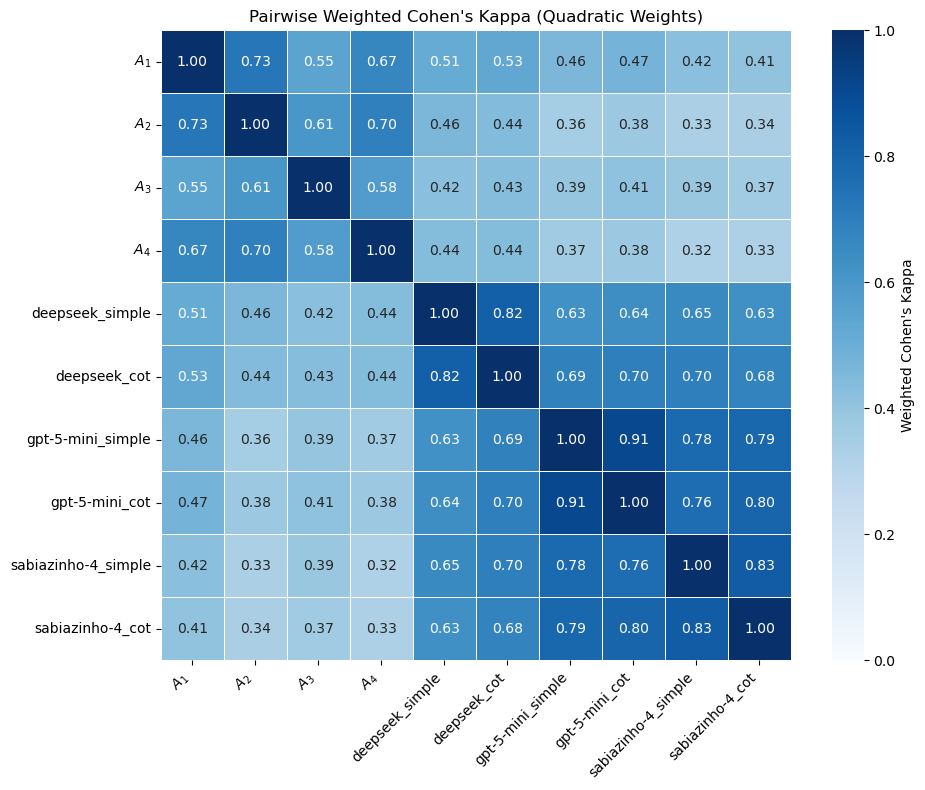

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que os valores são float
kappa_plot = kappa_matrix.astype(float)

# Cria figura maior (nomes longos precisam de espaço)
plt.figure(figsize=(10, 8))

# Converter labels para subscrito
kappa_plot.index = [f"${x}$" if x.startswith("A_") else x for x in kappa_plot.index]
kappa_plot.columns = [f"${x}$" if x.startswith("A_") else x for x in kappa_plot.columns]

# Adiciona máscara para mostrar matriz triangular
#mask = np.tril(np.ones_like(kappa_plot, dtype=bool), k=-1)
#mask = np.triu(np.ones_like(kappa_plot, dtype=bool), k=1)

ax = sns.heatmap(
    kappa_plot,
#    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Weighted Cohen's Kappa"}
)

plt.title("Pairwise Weighted Cohen's Kappa (Quadratic Weights)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
#plt.savefig("cohen_kappa_human_and_llm.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.4. Alpha de Krippendorff

Entre os anotadores humanos:

In [19]:
import krippendorff
import numpy as np

human_annotators = ["A_1", "A_2", "A_3", "A_4"]

# Matriz: linhas = anotadores, colunas = itens
data_human = wide[human_annotators].to_numpy().T

alpha_humans = krippendorff.alpha(
    reliability_data=data_human,
    level_of_measurement="ordinal"
)

print("Krippendorff alpha (Humans only):")
print(round(alpha_humans, 4))

Krippendorff alpha (Humans only):
0.6188
